<a href="https://colab.research.google.com/github/shuangquan-li-con/angrist-evans-1998-iv-replication/blob/main/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.sandbox.regression.gmm import IV2SLS

In [5]:
import os
if os.path.exists('/content/cleaned_combined_data.xlsx'):
  !file /content/cleaned_combined_data.xlsx
else:
  print('File not found at /content/cleaned_combined_data.xlsx')
df = pd.read_excel("/content/cleaned_combined_data.xlsx").copy()
print(df.shape)
df.head()


/content/cleaned_combined_data.xlsx: Microsoft Excel 2007+
(36009, 133)


,STATE,SEXK,AGEK,QTRBKID,RACEK,SPANISH,BIRTHPLK,SCHOOLK,GRADE,FINGRADE,...,INCOMED1,INCOMED2,ARACED,AAGED,AHISPD,ASCHD,AWKS89D,AHRS89D,AINCD1,AINCD2
0,1,1,16,3.0,1,0.0,1,1,13.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,17,3.0,1,0.0,1,1,14.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,17,4.0,1,0.0,1,1,12.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,14,1.0,2,0.0,1,1,9.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0,17,3.0,1,0.0,17,1,13.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df["samesex"] = np.where(
    df["SEX2NDK"].notna(),
    (df["SEXK"] == df["SEX2NDK"]).astype(int),
    np.nan
)

df["more2kids"] = (df["KIDCOUNT"] > 20).astype(int)

df["worked_89"] = (df["WEEK89M"] > 0).astype(int)
df["weeks_worked"] = df["WEEK89M"]
df["hours_worked"] = df["HOUR89M"].replace(99, np.nan)

df["age_sq"] = df["AGEM"] ** 2
df["black"] = (df["RACEM"] == 2).astype(int)
df["other_race"] = ((df["RACEM"] != 1) & (df["RACEM"] != 2)).astype(int)
df["hispanic"] = df["HISPM"].fillna(0).ne(0).astype(int)

analysis_vars = [
    "samesex", "more2kids", "worked_89", "weeks_worked", "hours_worked",
    "AGEM", "age_sq", "YEARSCHM", "black", "other_race", "hispanic", "MULTI2ND"
]

df_analysis = df[analysis_vars].dropna().copy()
print(df_analysis.shape)
df_analysis.head()

(35774, 12)


,samesex,more2kids,worked_89,weeks_worked,hours_worked,AGEM,age_sq,YEARSCHM,black,other_race,hispanic,MULTI2ND
88,0.0,0,1,52.0,40.0,35,1225,10.0,0,0,0,0.0
89,1.0,0,1,14.0,36.0,42,1764,14.0,0,0,0,0.0
90,1.0,0,0,0.0,0.0,33,1089,13.0,0,0,0,0.0
91,1.0,0,1,52.0,45.0,42,1764,11.0,0,0,0,0.0
92,1.0,1,1,15.0,12.0,29,841,11.0,0,0,0,0.0


In [7]:
df_no_twins = df_analysis[df_analysis["MULTI2ND"] != 10].copy()
print(df_no_twins.shape)

(35424, 12)


In [8]:
def run_models(data, outcome, controls=True):
    control_vars = ["AGEM", "age_sq", "black", "other_race", "hispanic", "YEARSCHM"] if controls else []

    # First stage
    X_fs = sm.add_constant(data[["samesex"] + control_vars])
    fs = sm.OLS(data["more2kids"], X_fs).fit(cov_type="HC1")

    # Reduced form
    X_rf = sm.add_constant(data[["samesex"] + control_vars])
    rf = sm.OLS(data[outcome], X_rf).fit(cov_type="HC1")

    # OLS
    X_ols = sm.add_constant(data[["more2kids"] + control_vars])
    ols = sm.OLS(data[outcome], X_ols).fit(cov_type="HC1")

    # IV
    X_iv = sm.add_constant(data[["more2kids"] + control_vars])
    Z_iv = sm.add_constant(data[["samesex"] + control_vars])
    iv = IV2SLS(data[outcome], X_iv, Z_iv).fit()

    return fs, rf, ols, iv

In [9]:
results = []

specs = [
    ("Employment, no controls", df_analysis, "worked_89", False),
    ("Employment, controls", df_analysis, "worked_89", True),
    ("Employment, controls, no twin 2nd birth", df_no_twins, "worked_89", True),
    ("Weeks worked, controls, no twin 2nd birth", df_no_twins, "weeks_worked", True),
    ("Hours worked, controls, no twin 2nd birth", df_no_twins, "hours_worked", True),
]

for spec_name, data_used, outcome, use_controls in specs:
    fs, rf, ols, iv = run_models(data_used, outcome, controls=use_controls)

    f_stat = float(fs.f_test("samesex = 0").fvalue)

    results.append({
        "Specification": spec_name,
        "N": len(data_used),
        "FirstStage_Coef": fs.params["samesex"],
        "FirstStage_SE": fs.bse["samesex"],
        "FirstStage_F": f_stat,
        "ReducedForm_Coef": rf.params["samesex"],
        "ReducedForm_SE": rf.bse["samesex"],
        "OLS_Coef": ols.params["more2kids"],
        "OLS_SE": ols.bse["more2kids"],
        "IV_Coef": iv.params["more2kids"],
        "IV_SE": iv.bse["more2kids"],
    })

results_df = pd.DataFrame(results)
results_df

,Specification,N,FirstStage_Coef,FirstStage_SE,FirstStage_F,ReducedForm_Coef,ReducedForm_SE,OLS_Coef,OLS_SE,IV_Coef,IV_SE
0,"Employment, no controls",35774,0.062361,0.004904,161.695149,-0.001341,0.004817,-0.116577,0.005339,-0.021499,0.077061
1,"Employment, controls",35774,0.061826,0.004826,164.153101,-0.001299,0.004769,-0.114421,0.005380,-0.021007,0.076968
2,"Employment, controls, no twin 2nd birth",35424,0.063425,0.004818,173.309730,-0.001258,0.004792,-0.115732,0.005450,-0.019840,0.075389
3,"Weeks worked, controls, no twin 2nd birth",35424,0.063425,0.004818,173.309730,-0.120071,0.234319,-6.644223,0.257516,-1.893136,3.677456
4,"Hours worked, controls, no twin 2nd birth",35424,0.063425,0.004818,173.309730,0.049243,0.193934,-4.780599,0.215013,0.776397,3.065237


In [10]:
display_cols = [
    "Specification", "N",
    "FirstStage_Coef", "FirstStage_SE", "FirstStage_F",
    "ReducedForm_Coef", "ReducedForm_SE",
    "OLS_Coef", "OLS_SE",
    "IV_Coef", "IV_SE"
]

results_df[display_cols].round(4)

,Specification,N,FirstStage_Coef,FirstStage_SE,FirstStage_F,ReducedForm_Coef,ReducedForm_SE,OLS_Coef,OLS_SE,IV_Coef,IV_SE
0,"Employment, no controls",35774,0.0624,0.0049,161.6951,-0.0013,0.0048,-0.1166,0.0053,-0.0215,0.0771
1,"Employment, controls",35774,0.0618,0.0048,164.1531,-0.0013,0.0048,-0.1144,0.0054,-0.0210,0.0770
2,"Employment, controls, no twin 2nd birth",35424,0.0634,0.0048,173.3097,-0.0013,0.0048,-0.1157,0.0054,-0.0198,0.0754
3,"Weeks worked, controls, no twin 2nd birth",35424,0.0634,0.0048,173.3097,-0.1201,0.2343,-6.6442,0.2575,-1.8931,3.6775
4,"Hours worked, controls, no twin 2nd birth",35424,0.0634,0.0048,173.3097,0.0492,0.1939,-4.7806,0.2150,0.7764,3.0652


In [15]:
results_df[display_cols].round(4).to_csv("phase3_results_table.csv", index=False)

This project first replicated the baseline relationship between fertility and maternal labor supply using an instrumental-variables strategy based on the same-sex composition of the first two children. In Phase 3, I extended the analysis by conducting weak-instrument and robustness diagnostics. Across all specifications, the instrument remains very strong in the first stage, with F-statistics well above the conventional threshold. This strengthens confidence in the credibility of the identification strategy.

t the same time, the 2SLS estimates are much smaller and less precise than the corresponding OLS estimates. While OLS suggests a strong negative relationship between having more than two children and maternal labor supply, the IV results imply that the causal effect is more modest and in many cases statistically imprecise. Overall, the extension does not weaken the identification strategy; instead, it shows that the instrument is strong but that the true causal effect is smaller and less stable than the baseline correlation would suggest.

In [11]:
for i, row in results_df.iterrows():
    print(f"{row['Specification']}:")
    print(f"  First-stage coef = {row['FirstStage_Coef']:.4f}")
    print(f"  Robust F-stat    = {row['FirstStage_F']:.2f}")
    print()

Employment, no controls:
  First-stage coef = 0.0624
  Robust F-stat    = 161.70

Employment, controls:
  First-stage coef = 0.0618
  Robust F-stat    = 164.15

Employment, controls, no twin 2nd birth:
  First-stage coef = 0.0634
  Robust F-stat    = 173.31

Weeks worked, controls, no twin 2nd birth:
  First-stage coef = 0.0634
  Robust F-stat    = 173.31

Hours worked, controls, no twin 2nd birth:
  First-stage coef = 0.0634
  Robust F-stat    = 173.31



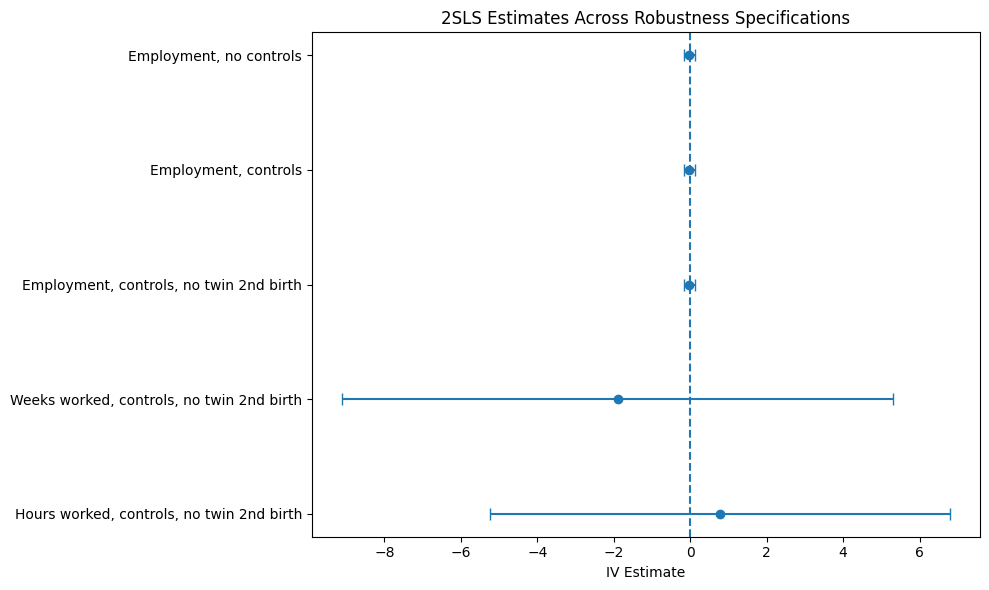

In [12]:
plot_df = results_df.copy()
plot_df["CI_Lower"] = plot_df["IV_Coef"] - 1.96 * plot_df["IV_SE"]
plot_df["CI_Upper"] = plot_df["IV_Coef"] + 1.96 * plot_df["IV_SE"]

plot_df = plot_df.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.errorbar(
    plot_df["IV_Coef"],
    plot_df["Specification"],
    xerr=[
        plot_df["IV_Coef"] - plot_df["CI_Lower"],
        plot_df["CI_Upper"] - plot_df["IV_Coef"]
    ],
    fmt="o",
    capsize=4
)
plt.axvline(x=0, linestyle="--")
plt.xlabel("IV Estimate")
plt.ylabel("")
plt.title("2SLS Estimates Across Robustness Specifications")
plt.tight_layout()
plt.show()

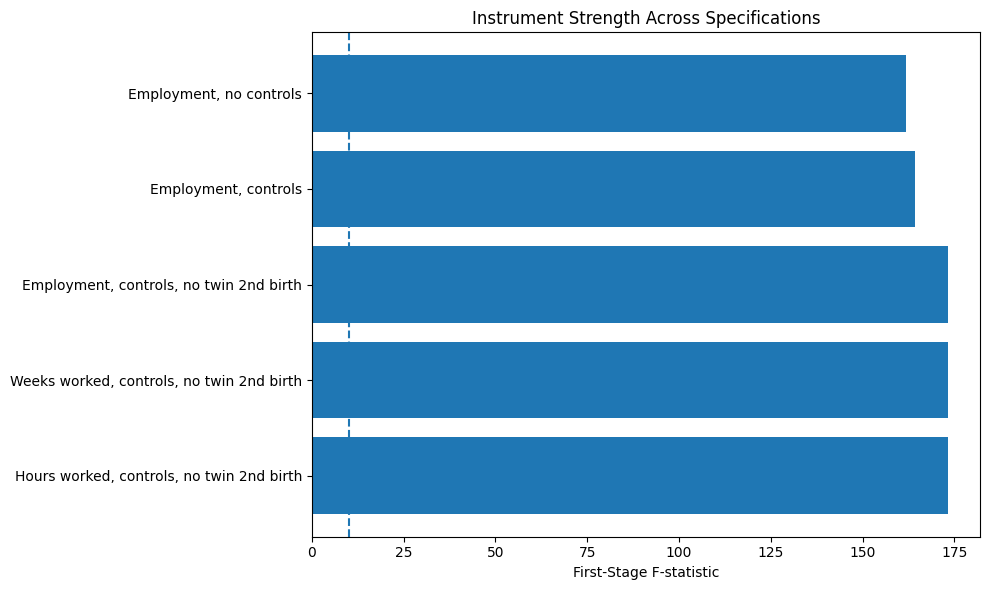

In [13]:
plot_df2 = results_df.copy().iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df2["Specification"], plot_df2["FirstStage_F"])
plt.axvline(x=10, linestyle="--")
plt.xlabel("First-Stage F-statistic")
plt.ylabel("")
plt.title("Instrument Strength Across Specifications")
plt.tight_layout()
plt.show()

The first-stage relationship is strong across specifications, with F-statistics well above the conventional threshold. This suggests that weak-instrument concerns are limited in this application. Compared with OLS, the 2SLS estimates are smaller and less precise, indicating that the raw negative correlation between larger family size and maternal labor supply likely overstates the causal effect. Overall, the robustness checks strengthen confidence in the identification strategy while also showing that the causal magnitude is more modest than the baseline correlation suggests.

## GenAI Usage Disclosure

In this phase, I used ChatGPT as a coding assistant and debugging partner. Specifically, I used it to help refactor Python code for IV estimation, generate plotting code for robustness visualizations, troubleshoot pandas and statsmodels issues, and improve the structure of markdown explanations. All econometric specifications, variable definitions, and final interpretations were reviewed and validated by me.

Example prompts:
- "Write Python code to compare first-stage, reduced-form, OLS, and 2SLS estimates across robustness specifications."
- "Generate a matplotlib coefficient plot for IV estimates with 95% confidence intervals."